# Used Car Price Explorer
### Exploratory Data Analysis & Price Prediction using
### Linear Regression and Random Forest Regression

## Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sns.set_style("whitegrid")
np.random.seed(42)
print("Libraries imported successfully.")

Libraries imported successfully.


## Create the Used-Car Dataset

In [7]:
# Simulated used-car listings dataset (brand, specs, condition -> selling price)
n = 1000
brands = ['Maruti', 'Hyundai', 'Honda', 'Toyota', 'Tata', 'Mahindra', 'Ford', 'Volkswagen']
fuel_types = ['Petrol', 'Diesel', 'CNG', 'Electric']
transmissions = ['Manual', 'Automatic']
owner_types = ['First', 'Second', 'Third', 'Fourth & Above']

In [8]:
brand_base_price = {'Maruti': 5.5, 'Hyundai': 6.5, 'Honda': 7.5, 'Toyota': 9.0,
'Tata': 5.0, 'Mahindra': 7.0, 'Ford': 6.0, 'Volkswagen': 7.8}

In [9]:
data = {
'brand': np.random.choice(brands, n),
'year': np.random.randint(2008, 2024, n),
'km_driven': np.random.randint(500, 180000, n),
'fuel_type': np.random.choice(fuel_types, n, p=[0.55, 0.30, 0.10, 0.05]),
'transmission': np.random.choice(transmissions, n, p=[0.7, 0.3]),
'owner_type': np.random.choice(owner_types, n, p=[0.55, 0.28, 0.12, 0.05]),
'mileage_kmpl': np.round(np.random.normal(18, 4, n).clip(8, 32), 1),
'engine_cc': np.random.choice([796, 998, 1197, 1248, 1498, 1598, 1998, 2179], n),
'power_bhp': np.round(np.random.normal(95, 30, n).clip(40, 260), 1),
'seats': np.random.choice([4, 5, 7], n, p=[0.05, 0.85, 0.10]),
}
df = pd.DataFrame(data)

In [10]:
car_age = 2024 - df['year']
base = df['brand'].map(brand_base_price)
price = (
base
- car_age * 0.28
- df['km_driven'] / 100000 * 1.1
+ df['power_bhp'] * 0.03
+ (df['transmission'] == 'Automatic') * 0.8
+ (df['fuel_type'] == 'Diesel') * 0.4
- (df['owner_type'] == 'Second') * 0.3
- (df['owner_type'] == 'Third') * 0.6
- (df['owner_type'] == 'Fourth & Above') * 1.0
+ np.random.normal(0, 0.5, n)
)
df['selling_price_lakhs'] = np.round(price.clip(0.5, None), 2)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 11)


,brand,year,km_driven,fuel_type,transmission,owner_type,mileage_kmpl,engine_cc,power_bhp,seats,selling_price_lakhs
0,Ford,2013,57634,Diesel,Automatic,First,18.8,1498,96.7,5,5.97
1,Toyota,2022,152063,Diesel,Automatic,First,18.7,1248,108.7,7,11.71
2,Tata,2008,132913,Petrol,Manual,First,20.8,1998,102.3,5,2.19
3,Ford,2016,176195,Petrol,Automatic,Second,22.5,2179,40.0,5,2.77
4,Honda,2008,90827,Petrol,Manual,Third,18.1,1197,60.6,5,3.46


## Preview the Data

In [11]:
print(df.head().to_string())

    brand  year  km_driven fuel_type transmission owner_type  mileage_kmpl  engine_cc  power_bhp  seats  selling_price_lakhs
0    Ford  2013      57634    Diesel    Automatic      First          18.8       1498       96.7      5                 5.97
1  Toyota  2022     152063    Diesel    Automatic      First          18.7       1248      108.7      7                11.71
2    Tata  2008     132913    Petrol       Manual      First          20.8       1998      102.3      5                 2.19
3    Ford  2016     176195    Petrol    Automatic     Second          22.5       2179       40.0      5                 2.77
4   Honda  2008      90827    Petrol       Manual      Third          18.1       1197       60.6      5                 3.46


## Dataset Info & Summary Statistics

In [12]:
df.info()
print()
print(df.describe().round(2).to_string())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                1000 non-null   object 
 1   year                 1000 non-null   int32  
 2   km_driven            1000 non-null   int32  
 3   fuel_type            1000 non-null   object 
 4   transmission         1000 non-null   object 
 5   owner_type           1000 non-null   object 
 6   mileage_kmpl         1000 non-null   float64
 7   engine_cc            1000 non-null   int64  
 8   power_bhp            1000 non-null   float64
 9   seats                1000 non-null   int64  
 10  selling_price_lakhs  1000 non-null   float64
dtypes: float64(3), int32(2), int64(2), object(4)
memory usage: 78.3+ KB

          year  km_driven  mileage_kmpl  engine_cc  power_bhp    seats  selling_price_lakhs
count  1000.00    1000.00       1000.00    1000.00    1000.00  1000.00        

## Check Missing Value

In [32]:
print("Missing values per column:")
print(df.isnull().sum().to_string())

Missing values per column:
brand                  0
year                   0
km_driven              0
fuel_type              0
transmission           0
owner_type             0
mileage_kmpl           0
engine_cc              0
power_bhp              0
seats                  0
selling_price_lakhs    0
car_age                0


## Price Distribution

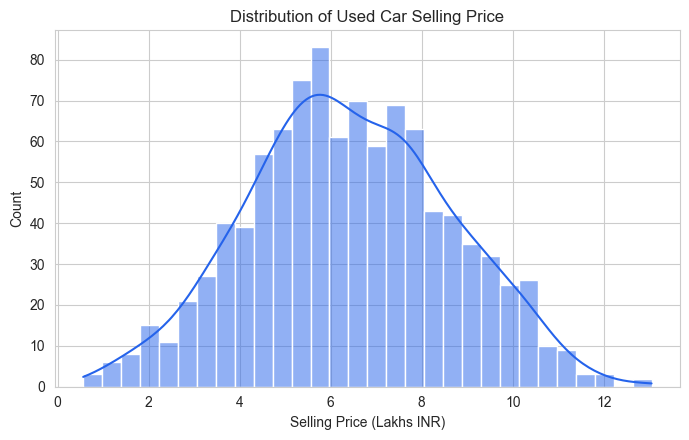

Saved: 01_price_distribution.png


In [33]:
plt.figure(figsize=(7, 4.5))
sns.histplot(df['selling_price_lakhs'], bins=30, kde=True, color='#2563eb')
plt.title('Distribution of Used Car Selling Price')
plt.xlabel('Selling Price (Lakhs INR)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
plt.savefig('plots/01_price_distribution.png', dpi=150)
plt.close()
print("Saved: 01_price_distribution.png")

## Correlation Heatmap

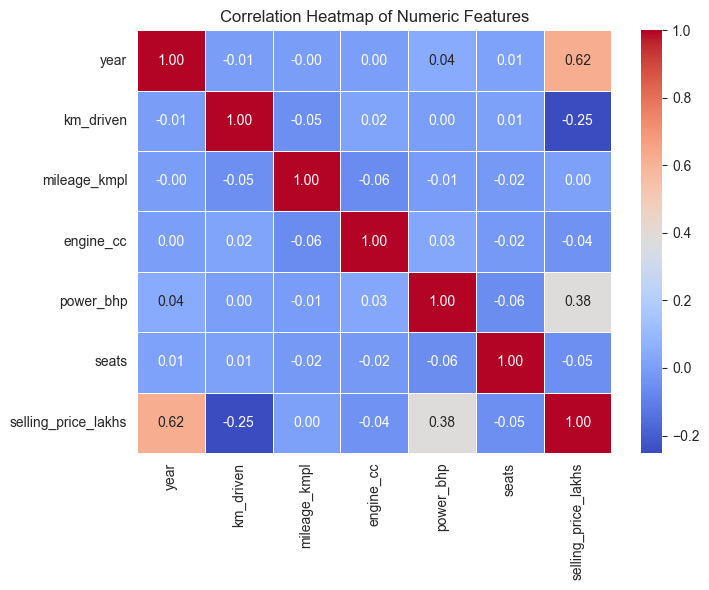

Saved: 02_correlation_heatmap.png


In [16]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(7.5, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()
plt.savefig('plots/02_correlation_heatmap.png', dpi=150)
plt.close()
print("Saved: 02_correlation_heatmap.png")

## Feature Engineering & Encoding

In [17]:
df['car_age'] = 2024 - df['year']


cat_cols = ['brand', 'fuel_type', 'transmission', 'owner_type']
label_encoders = {}
df_encoded = df.copy()
for col in cat_cols:
 le = LabelEncoder()
 df_encoded[col] = le.fit_transform(df_encoded[col])
label_encoders[col] = le


df_encoded = df_encoded.drop(columns=['year'])
print("Encoded feature columns:")
print(df_encoded.columns.tolist())

Encoded feature columns:
['brand', 'km_driven', 'fuel_type', 'transmission', 'owner_type', 'mileage_kmpl', 'engine_cc', 'power_bhp', 'seats', 'selling_price_lakhs', 'car_age']


## Train/Test Split & Scaling

In [18]:
X = df_encoded.drop(columns=['selling_price_lakhs'])
y = df_encoded['selling_price_lakhs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

Training set shape: (800, 10)
Testing set shape : (200, 10)


## Train Linear Regression

In [19]:
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
y_pred_lin = lin_model.predict(X_test_scaled)

lin_r2 = r2_score(y_test, y_pred_lin)
lin_mae = mean_absolute_error(y_test, y_pred_lin)
lin_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lin))

print("Linear Regression Performance")
print(f"R2 Score : {lin_r2:.4f}")
print(f"MAE : {lin_mae:.4f} Lakhs")
print(f"RMSE : {lin_rmse:.4f} Lakhs")

Linear Regression Performance
R2 Score : 0.6683
MAE : 1.0076 Lakhs
RMSE : 1.2659 Lakhs


## Train Random Forest Regressor

In [20]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Regressor Performance")
print(f"R2 Score : {rf_r2:.4f}")
print(f"MAE : {rf_mae:.4f} Lakhs")
print(f"RMSE : {rf_rmse:.4f} Lakhs")

Random Forest Regressor Performance
R2 Score : 0.8712
MAE : 0.6448 Lakhs
RMSE : 0.7890 Lakhs


## Compare Model Performance

            Model  R2 Score    MAE   RMSE
Linear Regression    0.6683 1.0076 1.2659
    Random Forest    0.8712 0.6448 0.7890


C:\Users\hp\AppData\Local\Temp\ipykernel_5940\3465362871.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=results, palette=['#93c5fd', '#2563eb'])


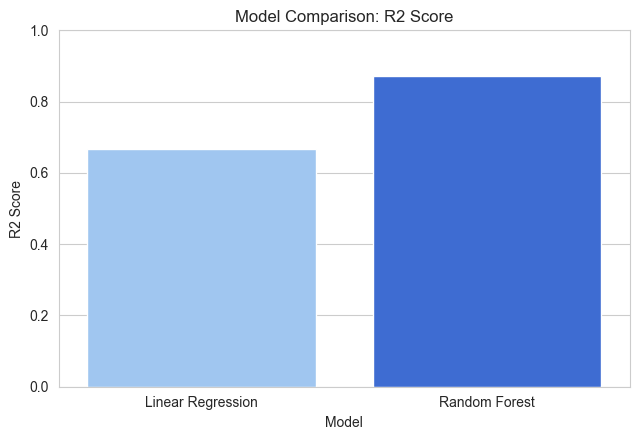

Saved: 03_model_comparison.png


In [21]:
results = pd.DataFrame({
'Model': ['Linear Regression', 'Random Forest'],
'R2 Score': [lin_r2, rf_r2],
'MAE': [lin_mae, rf_mae],
'RMSE': [rf_rmse if False else lin_rmse, rf_rmse]
})
print(results.round(4).to_string(index=False))

plt.figure(figsize=(6.5, 4.5))
sns.barplot(x='Model', y='R2 Score', data=results, palette=['#93c5fd', '#2563eb'])
plt.title('Model Comparison: R2 Score')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
plt.savefig('plots/03_model_comparison.png', dpi=150)
plt.close()
print("Saved: 03_model_comparison.png")

## Actual Vs Predicted Price

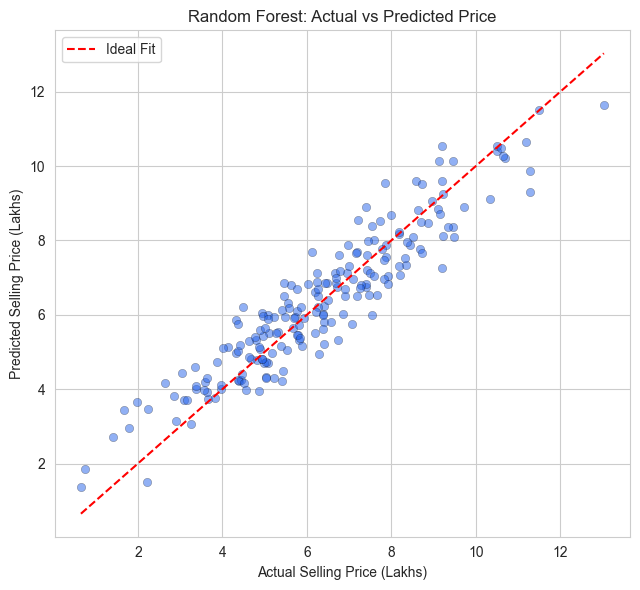

Saved: 04_actual_vs_predicted.png


In [22]:
plt.figure(figsize=(6.5, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='#2563eb', edgecolor='k', linewidth=0.3)
lims = [min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())]
plt.plot(lims, lims, 'r--', label='Ideal Fit')
plt.xlabel('Actual Selling Price (Lakhs)')
plt.ylabel('Predicted Selling Price (Lakhs)')
plt.title('Random Forest: Actual vs Predicted Price')
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig('plots/04_actual_vs_predicted.png', dpi=150)
plt.close()
print("Saved: 04_actual_vs_predicted.png")

## Feature Importance

Feature Importances (Random Forest):
car_age         0.4089
brand           0.2732
power_bhp       0.1761
km_driven       0.0789
mileage_kmpl    0.0226
engine_cc       0.0131
transmission    0.0089
owner_type      0.0077
fuel_type       0.0065
seats           0.0041


C:\Users\hp\AppData\Local\Temp\ipykernel_5940\1491811150.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')


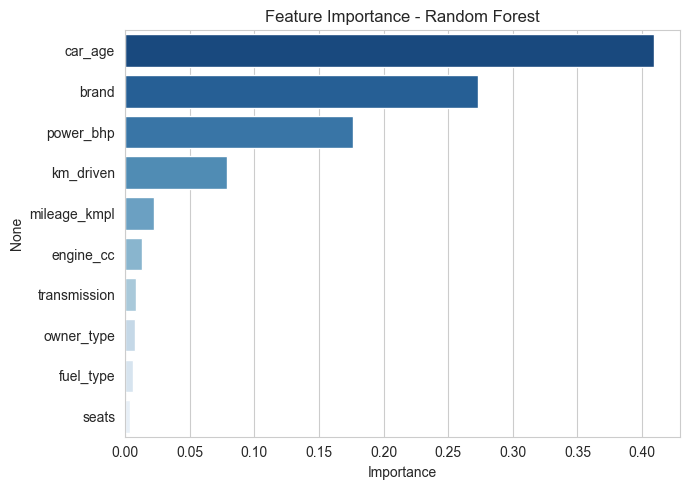

Saved: 05_feature_importance.png


In [23]:
importances = pd.Series(rf_model.feature_importances_,
index=X.columns).sort_values(ascending=False)
print("Feature Importances (Random Forest):")
print(importances.round(4).to_string())

plt.figure(figsize=(7, 5))
sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
plt.savefig('plots/05_feature_importance.png', dpi=150)
plt.close()
print("Saved: 05_feature_importance.png")

In [30]:
print(label_encoders.keys())

dict_keys(['brand', 'fuel_type', 'transmission', 'owner_type'])


## Predict Price for a New Car

In [31]:
sample_car = pd.DataFrame([{
'brand': label_encoders['brand'].transform(['Honda'])[0],
'km_driven': 45000,
'fuel_type': label_encoders['fuel_type'].transform(['Petrol'])[0],
'transmission': label_encoders['transmission'].transform(['Manual'])[0],
'owner_type': label_encoders['owner_type'].transform(['First'])[0],
'mileage_kmpl': 18.5,
'engine_cc': 1197,
'power_bhp': 88.0,
'seats': 5,
'car_age': 2024 - 2019,
}])[X.columns]

predicted_price = rf_model.predict(sample_car)[0]
print("Sample car: 2019 Honda, Petrol, Manual, First owner, 45,000 km")
print(f"Predicted Selling Price: {predicted_price:.2f} Lakhs INR")

Sample car: 2019 Honda, Petrol, Manual, First owner, 45,000 km
Predicted Selling Price: 7.21 Lakhs INR
